In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

files = os.listdir(path)
print("Files in the directory:", files)

csv_file = os.path.join(path, files[0]) 
df = pd.read_csv(csv_file)

print("\nData loaded successfully!")
print(df.head())

Files in the directory: ['SuperMarket Analysis.csv']

Data loaded successfully!
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:

In [2]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


1. What is the mean and median of the total sales?

In [3]:
mean_sales = df['gross income'].mean()
median_sales = df['gross income'].median()
print(f"Mean of sales: {mean_sales:.2f}")
print(f"Median of sales: {median_sales:.2f}")

Mean of sales: 15.38
Median of sales: 12.09


2. Which branch has the highest average sales? Show it graphically.

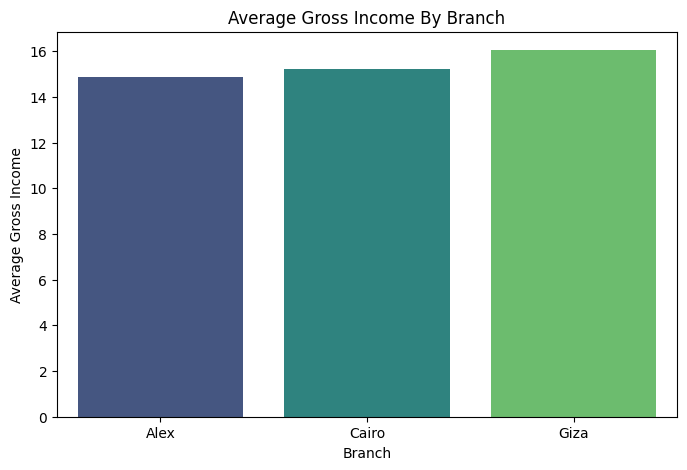

The branch with the highest average sales is Alex with 14.87


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

branch_sales = df.groupby('Branch')['gross income'].mean().reset_index()
branch_sales = branch_sales.sort_values('gross income', ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=branch_sales, x='Branch', y='gross income', hue='Branch', palette='viridis', legend=False)

plt.title('Average Gross Income By Branch')
plt.xlabel('Branch')
plt.ylabel('Average Gross Income')
plt.show()

top_branch = branch_sales.iloc[0]

print(f"The branch with the highest average sales is {top_branch['Branch']} with {top_branch['gross income']:,.2f}")

3. What are the ranges and the IQR (Interquartile Range) of the unit price?

In [5]:
price_range = df["Unit price"].max() - df["Unit price"].min()
iqr = np.percentile(df['Unit price'], 75) - np.percentile(df['Unit price'], 25)

print(f"Price range is: {price_range:.2f}")
print(f"IQR (Interquartile Range) is: {iqr:.2f}")


Price range is: 89.88
IQR (Interquartile Range) is: 45.06


In [ ]:
min_price = df['Unit price'].min()
max_price = df['Unit price'].max()

q1 = df['Unit price'].quantile(0.25)
q3 = df['Unit price'].quantile(0.75)

iqr = q3 - q1

print(f"Price Range: from {min_price:.2f} to {max_price:.2f}")
print(f"25th Percentile (Q1): {q1:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")

Price Range: from 10.08 to 99.96
25th Percentile (Q1): 32.88
75th Percentile (Q3): 77.94
Interquartile Range (IQR): 45.06


4. Check for outliers in the data. Visualize sales outliers using a boxplot.

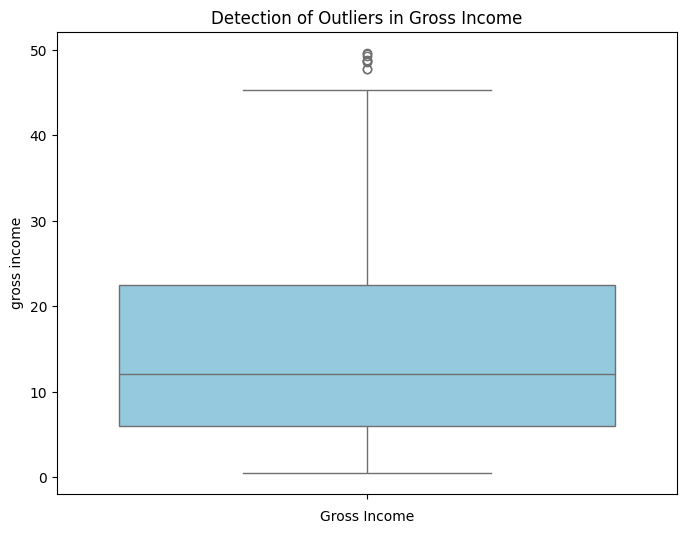

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(df['gross income'], color = 'skyblue')

plt.title('Detection of Outliers in Gross Income')
plt.xlabel('Gross Income')
plt.show()

5. What is the most common payment method?

payment methods usage:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


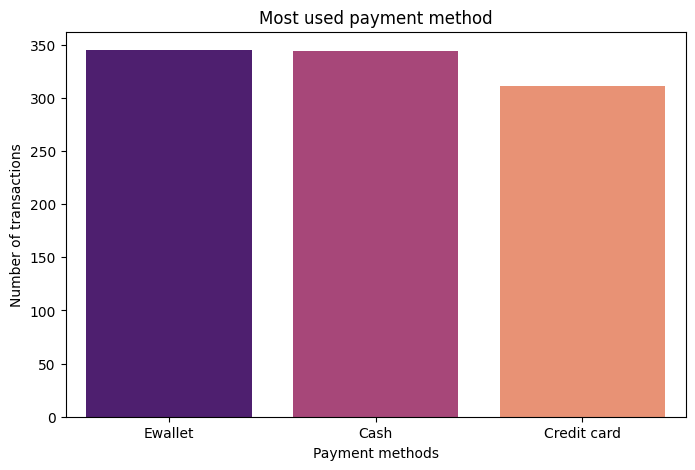


The most used payment method is: Ewallet


In [8]:
payment_counts = df['Payment'].value_counts()
print('payment methods usage:')
print(payment_counts)

plt.figure(figsize=(8,5))
sns.countplot(data= df, x='Payment', hue='Payment', palette='magma', legend=False)

plt.title('Most used payment method')
plt.xlabel('Payment methods')
plt.ylabel('Number of transactions')

plt.show()

most_common = payment_counts.idxmax()
print(f"\nThe most used payment method is: {most_common}")

6. What are the average sales by product line?

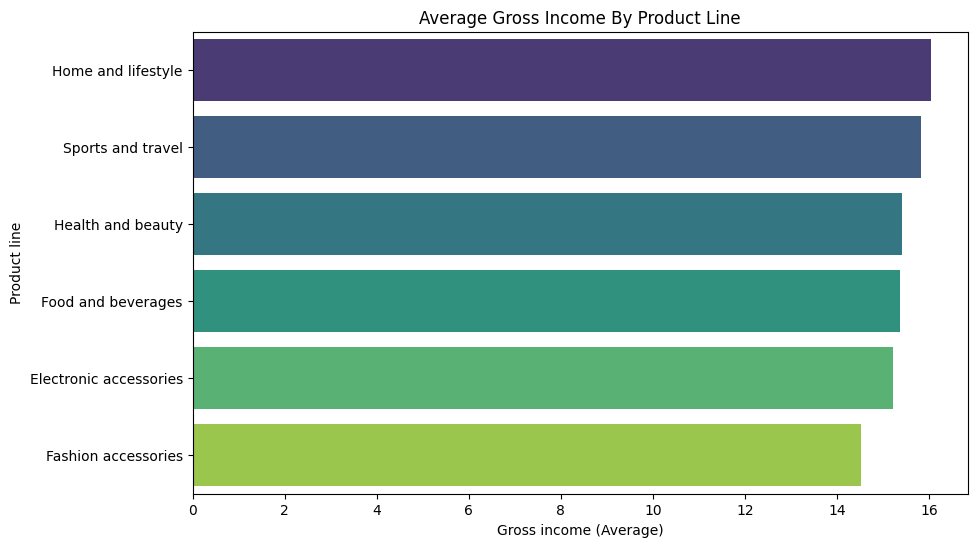

The most profitable product line is: Home and lifestyle


In [9]:
product_sales = df.groupby('Product line')['gross income'].mean().reset_index()
product_sales = product_sales.sort_values('gross income', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data = product_sales,
    y = 'Product line',
    x = 'gross income',
    hue = 'Product line',
    palette= 'viridis',
    legend = False
)
plt.title('Average Gross Income By Product Line')
plt.ylabel('Product line')
plt.xlabel('Gross income (Average)')

plt.show()

top_product_line = product_sales.iloc[0]
print(f"The most profitable product line is: {top_product_line['Product line']}")

7. Which customer type has a higher median sales value?

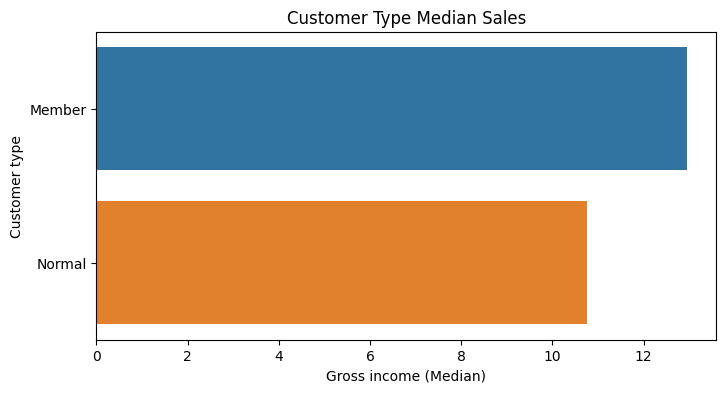

Customer type wih highest median sales value is Member with 12.95 median


In [10]:
customer_median = df.groupby('Customer type')['gross income'].median().reset_index()
customer_median = customer_median.sort_values('gross income', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(
    data = customer_median,
    y = 'Customer type',
    x = 'gross income',
    hue = 'Customer type',
    legend = False
)
plt.title('Customer Type Median Sales')
plt.ylabel('Customer type')
plt.xlabel('Gross income (Median)')
plt.show()

top_type = customer_median.iloc[0]
print(f"Customer type wih highest median sales value is {top_type['Customer type']} with {top_type['gross income']:.2f} median")